# Weather Data Analysis with Linear Regression

In this notebook I will try to analyze a weather dataset and apply **linear regression**.  
The goal is to predict some weather values (like temperature, rainfall, humidity) using available features.  

I will:  
1. Load the dataset  
2. Preprocess it (fix missing values, deal with the structure of the table)  
3. Visualize some features to understand the structure  
4. Define features and target variables  
5. Apply linear regression (ridge regression)  
6. Analyze the results  
7. Suggest improvements and real-world applications


In [97]:
# %%
# Import the needed libraries
import numpy as np
import pandas as pd
import calendar
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error, r2_score, make_scorer


## Step 1: Load the dataset

The dataset is in Excel format, and it has multiple sheets (monthly and yearly weather measurements).\
The excel file is uploaded to my github repo, and it's cloned in this notebook directly from the repo.\
I will load the sheets into pandas DataFrames.



In [98]:
# %%
# Load the dataset from Excel file
!git clone https://github.com/Suhaib-AbuRaidah/Intro2ML_Assignments.git
dfm = pd.read_excel("./Intro2ML_Assignments/Assignment_2_problem_2/Weather-1996-20181.xls", sheet_name=1)
dfy = pd.read_excel("./Intro2ML_Assignments/Assignment_2_problem_2/Weather-1996-20181.xls", sheet_name=2)

print("dfm shape:", dfm.shape)
print("dfy shape:", dfy.shape)

fatal: destination path 'Intro2ML_Assignments' already exists and is not an empty directory.
dfm shape: (309, 49)
dfy shape: (52, 27)


## Step 2: Preprocess the dataset

This part is the hardest, since the dataset has:  
- Multiple stations (airport, golf, zahle, tripoli)  
- The "month" column is text (needs to be converted)  
- Some typos (e.g. "Febraury")  
- Missing values (need to fill them properly)  

### Location encoding  
Since the dataset comes from **4 different locations**, we need a way for the model to know which row belongs to which place.  
If we just stack them together, the model won’t know whether a row is from Airport or Zahle.  

To fix this, I added a column called **`location`** that assigns:  
- `0` → Airport  
- `1` → Golf  
- `2` → Zahle  
- `3` → Tripoli  

Then I converted this into **dummy variables (one-hot encoding)** so the model can use it.  
This way, the regression can learn patterns specific to each location.



In [99]:
# %%
# dfm.head(15)  # get an idea of the structure of the table.

In [100]:
# %%
# define feature and target column indices for each location
airport_feat = [i for i in range(5,13)]
airport_targ = [i for i in range(3,5)]
golf_feat = [i for i in range(17,25)]
golf_targ = [i for i in range(15,17)]
zahle_feat = [i for i in range(29,37)]
zahle_targ = [i for i in range(27,29)]
tripoli_feat = [i for i in range(40,48)]
tripoli_targ = [i for i in range(38,40)]
data_range = [i for i in range(5,305)]
month_column = 1

# make features for each location
airport_features = pd.concat([dfm.iloc[data_range, month_column], dfm.iloc[data_range, airport_feat]], axis=1, ignore_index=True)
golf_features = pd.concat([dfm.iloc[data_range, month_column], dfm.iloc[data_range, golf_feat]], axis=1, ignore_index=True)
zahle_features = pd.concat([dfm.iloc[data_range, month_column], dfm.iloc[data_range, zahle_feat]], axis=1, ignore_index=True)
tripoli_features = pd.concat([dfm.iloc[data_range, month_column], dfm.iloc[data_range, tripoli_feat]], axis=1, ignore_index=True)

# merge features
features = pd.concat([airport_features, golf_features, zahle_features, tripoli_features], axis=0).reset_index(drop=True)

# add location encoding
features["location"] = pd.Series(0, index=np.arange(len(data_range)))
features.iloc[len(data_range):2*len(data_range),9] = 1
features.iloc[2*len(data_range):3*len(data_range),9] = 2
features.iloc[3*len(data_range):4*len(data_range),9] = 3 
features = pd.get_dummies(features, columns=['location'], drop_first=True)



### Clean the month column

The month column has issues:  
- Some rows have "Total yearly values" (they are summaries, not useful for regression, so I removed them).  
- There is a typo in "February" written as "Febraury" (fixed manually).  
- I mapped the month names into numbers (January = 1, ..., December = 12).  

After that, I applied **cyclical encoding** using **sine and cosine transformation**:  

month_sin = sin(2π * month / 12)  
month_cos = cos(2π * month / 12)

This way, December (12) and January (1) are close to each other again (since weather is seasonal).  
If I only used month numbers, the model would think month 12 and month 1 are far apart, which is wrong.


In [101]:
# %%
# rename columns based on the headers in dfm
features = features.rename(columns={0:'month', 1:dfm.iloc[4,5], 2:dfm.iloc[4,6],
                        3:dfm.iloc[4,7],4:dfm.iloc[4,8],
                        5:dfm.iloc[4,9],6:dfm.iloc[4,10],
                        7:dfm.iloc[4,11], 8:dfm.iloc[4,12]})

# remove "Total" rows
mask = ~features['month'].str.contains("Total", na=False)
features = features[mask].reset_index(drop=True)

# clean month names
features['month_clean'] = features['month'].str.split('/').str[1].str.strip()
features['month_clean'] = features['month_clean'].replace({'Febraury': 'February'})

# map months to numbers
month_map = {month: i for i, month in enumerate(calendar.month_name) if month}
features['month_num'] = features['month_clean'].map(month_map)
# convert columns to numeric
for col in features.columns:
    if col != 'month':
        features[col] = pd.to_numeric(features[col], errors='coerce')

# fill missing values with monthly means
numeric_cols = features.select_dtypes(include=np.number).columns.drop('month_num')
features[numeric_cols] = features.groupby('month_num')[numeric_cols].transform(lambda x: x.fillna(x.mean()))

# add cyclical encoding for month
features['month_sin'] = np.sin(2 * np.pi * features['month_num']/12)
features['month_cos'] = np.cos(2 * np.pi * features['month_num']/12)

# drop unused columns
month_features = features[['month_sin', 'month_cos']]
features = features.drop(columns=['month','month_clean','month_num','month_sin','month_cos'])
features = pd.concat([month_features, features], axis=1)

features.head(13)



,month_sin,month_cos,Mm de pluie / Mm of rain / ملم أمطار,Humidité relative (%) moyenne / Average relative Humidity (%) / الرطوبة النسبية المتوسطة (%),Humidité relative (%) maximale / Maximum relative Humidity (%) / الرطوبة النسبية القصوى (%),Humidité relative minimale (%) / Minimum relative Humidity (%) / الرطوبة النسبية الدنيا (%),Force du vent maximale (m/sec) / Wind maximum power (m/sec) / قوة الهواء القصوى (م/ثانية),Direction du vent maximale (degrés) / Maximal wind direction (degrees) / سرعة الهواء القصوى (درجة),Force du vent moyenne (m/sec) / Wind Average power (m/sec) / قوة الهواء المتوسطة (م/ثانية),Jours de pluie / Rainy Days / أيام ممطرة,location_1.0,location_2.0,location_3.0
0,5.000000e-01,8.660254e-01,217.4,69.0,92.664286,32.484847,20.007540,225.635714,14.427333,20.0,0.0,0.0,0.0
1,8.660254e-01,5.000000e-01,63.4,65.0,91.446341,30.872384,20.119312,238.145238,12.137600,10.0,0.0,0.0,0.0
2,1.000000e+00,6.123234e-17,182.0,70.0,91.126829,27.726144,19.693915,245.450000,14.383040,21.0,0.0,0.0,0.0
3,8.660254e-01,-5.000000e-01,57.8,67.0,90.385366,24.489659,17.643651,240.364286,11.478760,11.0,0.0,0.0,0.0
4,5.000000e-01,-8.660254e-01,0.2,76.0,89.904878,27.770248,16.846032,232.100000,14.683720,1.0,0.0,0.0,0.0
5,1.224647e-16,-1.000000e+00,0.4,67.0,87.848780,31.419130,14.451481,231.366667,13.864880,0.0,0.0,0.0,0.0
6,-5.000000e-01,-8.660254e-01,0.0,74.0,86.934146,37.189963,13.950106,244.204762,14.275640,0.0,0.0,0.0,0.0
7,-8.660254e-01,-5.000000e-01,0.0,71.0,87.463415,35.824390,13.212010,241.535714,12.835480,0.0,0.0,0.0,0.0
8,-1.000000e+00,-1.836970e-16,3.8,65.0,87.482927,32.204878,14.029021,235.240476,12.805560,2.0,0.0,0.0,0.0
9,-8.660254e-01,5.000000e-01,169.4,63.0,87.770732,27.826829,15.757248,233.233333,14.355208,12.0,0.0,0.0,0.0


### Final structure of the features

After preprocessing, the feature matrix (`X`) shown above has:  
1. **Month encoding** (2 columns: `month_sin`, `month_cos`)  
2. **Weather measurements** from each location (like temperature, rainfall, humidity, etc.), \
For empty weather measurments values at a given month, I replaced them with the average of these values at that given month throughout the years.  
3. **Location dummy variables** (3 columns, because we drop the first one to avoid collinearity):\
**(0,0,0)**: Airport\
**(1,0,0)**: Golf\
**(0,1,0)**: Zahle'\
**(0,0,1)**: Tripoli  

So the final features combine **time information (seasonality)** + **weather values** + **location info**.  

This gives the regression model enough context to learn patterns for each place and each season.


## Step 3: Define target variable

We take the target values for each location and merge them together.\
The target values are choosen to be the monthly max-temperature and min-temperature.\
The average temperature is ignored because it's redundant, it's just the average of the above two features.

In [102]:
# %%
airport_target = dfm.iloc[data_range, airport_targ].reset_index(drop=True)
golf_target = dfm.iloc[data_range, golf_targ].reset_index(drop=True)
zahle_target = dfm.iloc[data_range, zahle_targ].reset_index(drop=True)
tripoli_target = dfm.iloc[data_range, tripoli_targ].reset_index(drop=True)

target = pd.concat([airport_target, golf_target, zahle_target, tripoli_target], axis=0).reset_index(drop=True)

## rename target columns
target=target.rename(columns={'Unnamed: 3':dfm.iloc[4,3], 'Unnamed: 4':dfm.iloc[4,4]})
target = target.drop(columns=[target.columns[2],target.columns[3],target.columns[4],target.columns[5],target.columns[6],target.columns[7]])

# remove "Total" rows
target = target[mask.reset_index(drop=True)].reset_index(drop=True)

# remove NaN
nan_mask = ~target.iloc[:,0].isna().reset_index(drop=True)
target = target[nan_mask].reset_index(drop=True)
features = features[nan_mask].reset_index(drop=True)

print("features shape:", features.shape)
print("target shape:", target.shape)


features shape: (216, 13)
target shape: (216, 2)


## Step 4: Train/Test split and scaling

I will scale the features because regression works better with normalized data.


In [103]:
# %%
X = features.values
y = target.values

scale = StandardScaler()
X_scaled = scale.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.15, random_state=42)

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)


X_train: (183, 13)
y_train: (183, 2)


## Step 5: Apply Linear Regression and Ridge Regression
I will first use Ridge regression with cross-validation to evaluate the performance.


In [104]:
# %%
model = Ridge(alpha=0.1)

kf = KFold(n_splits=5, shuffle=True, random_state=42)
mse_scorer = make_scorer(mean_squared_error, greater_is_better=False)
r2_scorer = make_scorer(r2_score)

mse_scores = cross_val_score(model, X_scaled, y, cv=kf, scoring=mse_scorer)
r2_scores = cross_val_score(model, X_scaled, y, cv=kf, scoring=r2_scorer)

print("=== Ridge Regression with 5-Fold CV ===\n")
print("MSE per fold:", -mse_scores,"\n")
print("Mean MSE:", -mse_scores.mean())


=== Ridge Regression with 5-Fold CV ===

MSE per fold: [4.38543179 3.63570437 5.00434854 4.14721653 4.47282793] 

Mean MSE: 4.329105830764652


## Step 6: Final Model Evaluation
Train on train split and test on held-out set.


In [105]:
# %%
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("Test MSE:", mean_squared_error(y_test, y_pred))

Test MSE: 4.64452117381013


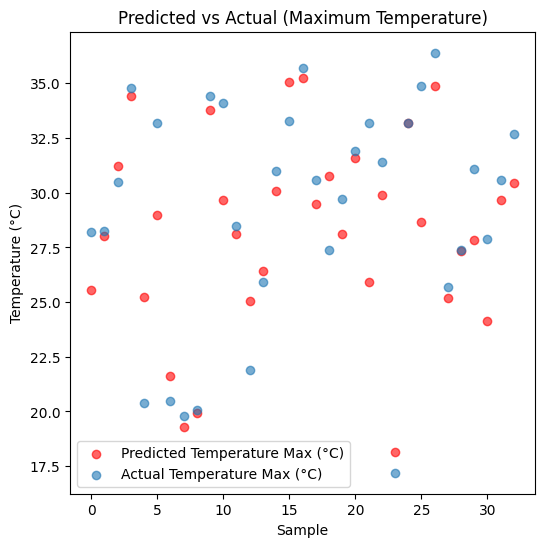

In [106]:
# %%
# plot predicted vs actual
plt.figure(figsize=(6,6))
plt.scatter(np.arange(len(y_pred)), y_pred[:,0],color='r', alpha=0.6, label="Predicted Temperature Max (°C)")
plt.scatter(np.arange(len(y_test)), y_test[:,0], alpha=0.6, label="Actual Temperature Max (°C)")
plt.xlabel("Sample")
plt.ylabel("Temperature (°C)")
plt.title("Predicted vs Actual (Maximum Temperature)")
plt.legend()
plt.show()


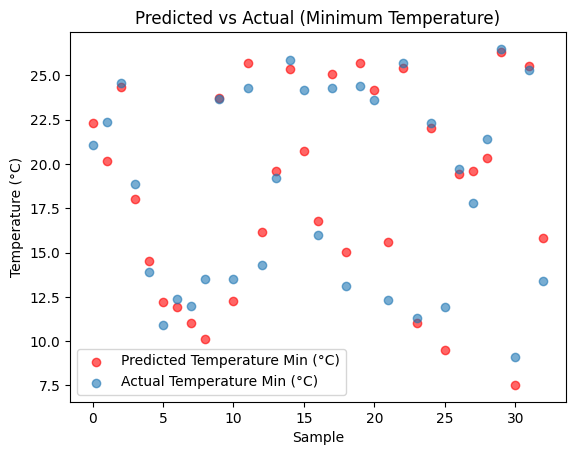

In [107]:
plt.scatter(np.arange(len(y_pred)), y_pred[:,1],color='r', alpha=0.6, label="Predicted Temperature Min (°C)")
plt.scatter(np.arange(len(y_test)), y_test[:,1], alpha=0.6, label="Actual Temperature Min (°C)")
plt.xlabel("Sample")
plt.ylabel("Temperature (°C)")
plt.title("Predicted vs Actual (Minimum Temperature)")
plt.legend()
plt.show()

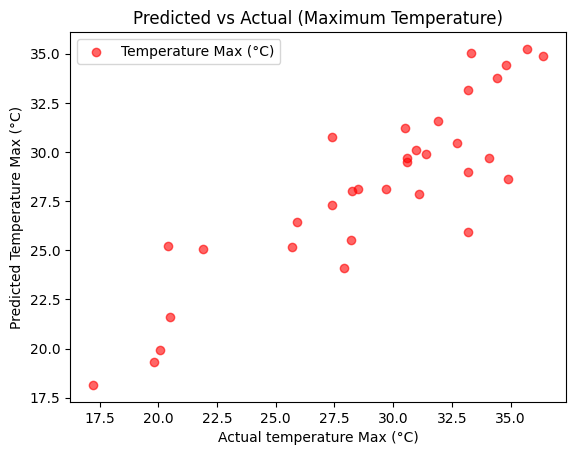

In [108]:
plt.scatter(y_test[:,0], y_pred[:,0],color='r', alpha=0.6, label="Temperature Max (°C)")
plt.xlabel("Actual temperature Max (°C)")
plt.ylabel("Predicted Temperature Max (°C)")
plt.title("Predicted vs Actual (Maximum Temperature)")
plt.legend()
plt.show()

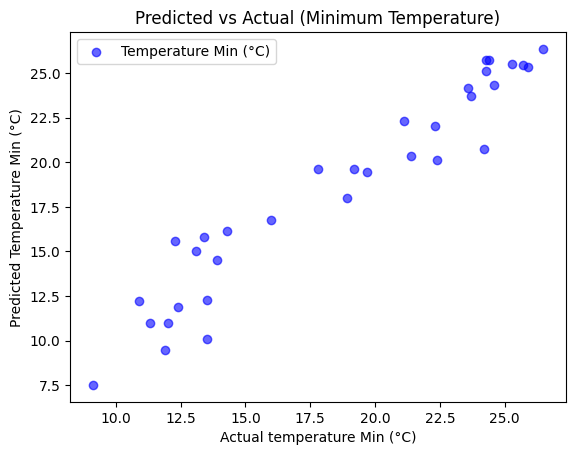

In [109]:
plt.scatter(y_test[:,1], y_pred[:,1],color='b', alpha=0.6, label="Temperature Min (°C)")
plt.xlabel("Actual temperature Min (°C)")
plt.ylabel("Predicted Temperature Min (°C)")
plt.title("Predicted vs Actual (Minimum Temperature)")
plt.legend()
plt.show()

## Step 7: Improvements

- Try PolynomialFeatures to capture non-linear relations  
- Tune `alpha` in Ridge regression, or try Lasso/ElasticNet  
- Add more weather variables (humidity, rain, pressure) if available
- Features empty values were dealt with by filling them with average values, however, target rows \
with empty values were simply ommited because there is no meaning in filling the values of the target.\
 An improvement could be done by finding a way to deal with NaN values in the target.

## Step 8: Real-world Applications

- Predicting **monthly average temperatures** for agriculture planning  
- Estimating **rainfall** for water resource management  
- Assisting **energy companies** in predicting electricity demand (since temperature affects AC/heating usage)  
- Helping **tourism and outdoor activities** planning (like golf, skiing)  
